In [2]:
import time
from itertools import product, combinations

import numpy as np
import pandas as pd
import gurobipy as gb
from sklearn.linear_model import LinearRegression


# WLS credentials
# WLSACCESSID = 'ccc2c36a-db14-4956-b2e3-60adc45e9957'
WLSACCESSID = '0b6da3bd-b422-4071-871e-4b307ca642eb'
# WLSSECRET = '1e0e3dbf-7933-44dc-8f81-e0482ded7ac8'
WLSSECRET='7757bb3c-fca9-4e07-8569-8ea80f663a36'
LICENSEID=2586688

# Create the Gurobi environment with parameters
env = gb.Env(empty=True)  # Start with an empty environment
env.setParam('WLSACCESSID', WLSACCESSID)
env.setParam('WLSSECRET', WLSSECRET)
env.setParam('LICENSEID', LICENSEID)
env.start() 

Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2586688
Academic license 2586688 - for non-commercial use only - registered to ru___@ucsd.edu


<gurobipy.Env, Parameter changes: WLSAccessID=(user-defined), WLSSecret=(user-defined), LicenseID=2586688>

In [3]:
df = pd.read_csv('GA_features.csv')
df.columns

Index(['Unnamed: 0.3', 'Unnamed: 0.2', 'Unnamed: 0', 'Unnamed: 0.1', 'county',
       'tweets', 'contribution', 'n_poll', 'frac_unem', 'frac_votes',
       ...
       'frac_voted_A', 'frac_voted_B', 'frac_voted_C', 'frac_voted_D',
       'frac_voted_E', 'frac_voted_F', 'frac_voted_G', 'total_registers',
       'latitude', 'longitude'],
      dtype='object', length=126)

In [4]:
import os
import numpy as np
import pandas as pd
import gurobipy as gb
from sklearn.linear_model import LinearRegression

# -----------------------------
# Setup and Data Loading
# -----------------------------

# WLS credentials
WLS_ACCESS_ID = 'ccc2c36a-db14-4956-b2e3-60adc45e9957'
WLS_SECRET = '1e0e3dbf-7933-44dc-8f81-e0482ded7ac8'
LICENSE_ID = 2586688

# Create the Gurobi environment with parameters
env = gb.Env(empty=True)
env.setParam('WLSACCESSID', WLS_ACCESS_ID)
env.setParam('WLSSECRET', WLS_SECRET)
env.setParam('LICENSEID', LICENSE_ID)
env.start()

# Load data and neighborhood matrices
try:
    df = pd.read_csv('GA_features.csv')
    NEIGHBOR_INDEX_MATRIX = np.load('index_matrix.npy')
    NEIGHBOR_DISTANCE_MATRIX = np.load('distance_matrix.npy')
except FileNotFoundError as e:
    print(f"Error loading data files: {e}")
    exit()

# -----------------------------
# Constants and Columns
# -----------------------------
SOCIAL_CATEGORIES = ['A', 'B', 'C', 'D', 'E', 'F', 'G']
TAU_TIGHTEST = 0.4  # Tightest fairness constraint
TAU_NONE = None   # No fairness constraint

FEATURE_COLUMNS = ['frac_unem', 'n_poll', 'contribution', 'tweets']
COUNT_COLUMNS = [f'registered_{cat}' for cat in SOCIAL_CATEGORIES]
FRAC_COLUMNS = [f'frac_registered_{cat}' for cat in SOCIAL_CATEGORIES]

# -----------------------------
# Prepare Features and Targets
# -----------------------------
X = df[FEATURE_COLUMNS]
A_frac = df[FRAC_COLUMNS]
y_train = df['frac_votes'].values

# Feature values
UNEMPLOYMENT_RATE = X['frac_unem'].values
POLLING_STATIONS = X['n_poll'].values
CONTRIBUTION = np.ones_like(X['contribution'].values)  # Constant vector for contribution
TWEETS = X['tweets'].values

# Neighborhood dimensions and intervention space
NUM_COUNTIES = X.shape[0]
NUM_NEIGHBORS = NEIGHBOR_INDEX_MATRIX.shape[1]
INTERVENTION_SAMPLE_SPACES = [(0, 1)] * NUM_NEIGHBORS
POSSIBLE_INTERVENTIONS_MATRIX = np.array(list(product(*INTERVENTION_SAMPLE_SPACES)))
NUM_POSSIBLE_INTERVENTIONS = POSSIBLE_INTERVENTIONS_MATRIX.shape[0]

# -----------------------------
# Regression Model Setup
# -----------------------------
def compute_adjusted_features(feature_values, A_frac, neighbor_distance_matrix):
    """
    Compute the maximum influence from neighbors and multiply elementwise with A_frac.
    """
    max_neighbor_influence = np.max(neighbor_distance_matrix * feature_values[:, None], axis=1).reshape(NUM_COUNTIES, 1)
    return A_frac * max_neighbor_influence

# Compute adjusted features for each feature
adjusted_unemployment = A_frac * UNEMPLOYMENT_RATE.reshape(NUM_COUNTIES, 1)
adjusted_polling = compute_adjusted_features(POLLING_STATIONS, A_frac, NEIGHBOR_DISTANCE_MATRIX)
adjusted_contribution = compute_adjusted_features(CONTRIBUTION, A_frac, NEIGHBOR_DISTANCE_MATRIX)
adjusted_tweets = A_frac * TWEETS.reshape(NUM_COUNTIES, 1)

# Combine features and train regression model (no intercept)
X_train = np.concatenate((adjusted_unemployment, adjusted_polling, adjusted_contribution, adjusted_tweets, A_frac), axis=1)
linear_model = LinearRegression(fit_intercept=False).fit(X_train, y_train)
model_weights = linear_model.coef_
param_dims = len(SOCIAL_CATEGORIES)

# Split regression weights into groups corresponding to each feature and demographics
weight_dict = {
    'alpha': model_weights[:param_dims],
    'beta': model_weights[param_dims:2*param_dims],
    'gamma': model_weights[2*param_dims:3*param_dims],
    'delta': model_weights[3*param_dims:4*param_dims],
    'theta': model_weights[4*param_dims:]
}
params = pd.DataFrame(weight_dict, index=SOCIAL_CATEGORIES)
ALPHA = params['alpha'].values
BETA = params['beta'].values
GAMMA = params['gamma'].values
DELTA = params['delta'].values
THETA = params['theta'].values

# -----------------------------
# Impact Calculation Functions
# -----------------------------
def calculate_expected_impact(index, intervention_array, demographic_vector):
    """
    Calculate the expected impact for a single county using the intervention decision.
    For each term, we multiply the (binary) intervention vector by the neighbor distances,
    take the maximum value, and weight it by the corresponding regression coefficient.
    """
    # Get the indices and distances of the county's neighbors
    nearest_neighbors = NEIGHBOR_INDEX_MATRIX[index, :]
    neighbor_distances = NEIGHBOR_DISTANCE_MATRIX[index, nearest_neighbors]
    
    unemployment_term = np.dot(demographic_vector, ALPHA) * np.max(neighbor_distances * intervention_array)
    polling_term = np.dot(demographic_vector, BETA) * np.max(neighbor_distances * POLLING_STATIONS[nearest_neighbors])
    contribution_term = np.dot(demographic_vector, GAMMA) * np.max(neighbor_distances * CONTRIBUTION[nearest_neighbors])
    tweets_term = np.dot(demographic_vector, DELTA) * np.max(neighbor_distances * TWEETS[nearest_neighbors])
    demographic_term = np.dot(demographic_vector, THETA)
    
    impact = unemployment_term + polling_term + contribution_term + tweets_term + demographic_term
    return max(min(impact, 1), 0)

def calculate_all_possible_impacts(index, demographic_vector):
    """
    Compute the expected impact for all possible neighbor intervention patterns.
    """
    possible_impacts = np.empty(NUM_POSSIBLE_INTERVENTIONS)
    for k, intervention_array in enumerate(POSSIBLE_INTERVENTIONS_MATRIX):
        possible_impacts[k] = calculate_expected_impact(index, intervention_array, demographic_vector)
    return possible_impacts

def calculate_total_impact(intervention_array):
    """
    Calculate the total impact over all counties given a binary intervention solution.
    """
    total_impact = 0
    for i in range(NUM_COUNTIES):
        demographic_vector = A_frac.values[i, :]
        total_impact += calculate_expected_impact(i, intervention_array[i], demographic_vector)
    return total_impact

# -----------------------------
# Optimization Routine
# -----------------------------
def optimize_interventions(tau_value, budget):
    """
    Optimize the intervention decisions for all counties under a budget constraint.
    A fairness constraint (tau) may be imposed. For each county the model selects
    an intervention pattern (from a discrete set) that yields a factual impact,
    while the fairness constraints force the differences in impact (for each demographic group)
    to be within tau.
    """
    print(f'Running optimization for tau={tau_value} and budget={budget}')
    model = gb.Model(env=env)
    
    # Binary variables for each county
    interventions = model.addVars(NUM_COUNTIES, vtype=gb.GRB.BINARY, name="interventions")
    model.addConstr(sum(interventions[i] for i in range(NUM_COUNTIES)) <= budget, "budget_constraint")
    
    # For each county, create auxiliary variables for each possible intervention pattern
    for index in range(NUM_COUNTIES):
        demographic_vector = A_frac.values[index, :]
        factual_impacts = calculate_all_possible_impacts(index, demographic_vector)
        auxiliary_vars = model.addVars(len(factual_impacts), obj=factual_impacts, vtype=gb.GRB.CONTINUOUS, name=f"aux_{index}")
        model.update()
        
        # Link the auxiliary variables to the intervention decisions of the neighbors
        for j, intervention_pattern in enumerate(POSSIBLE_INTERVENTIONS_MATRIX):
            for k, neighbor in enumerate(NEIGHBOR_INDEX_MATRIX[index, :]):
                if intervention_pattern[k] == 1:
                    model.addConstr(auxiliary_vars[j] <= interventions[int(neighbor)])
                else:
                    model.addConstr(auxiliary_vars[j] <= 1 - interventions[int(neighbor)])
        model.addConstr(sum(auxiliary_vars[j] for j in range(len(factual_impacts))) == 1)
        
        # If a fairness constraint is imposed, add constraints on group impact differences
        if tau_value is not None:
            for group_idx in range(A_frac.shape[1]):
                group_indicator = np.eye(A_frac.shape[1])[group_idx]
                group_impact_diff = calculate_all_possible_impacts(index, group_indicator) - factual_impacts
                model.addConstr(
                    sum(auxiliary_vars[j] * group_impact_diff[j] for j in range(len(factual_impacts))) <= tau_value
                )
    
    model.setObjective(model.getObjective(), gb.GRB.MAXIMIZE)
    model.optimize()
    
    if model.status == gb.GRB.OPTIMAL:
        solution = np.array([interventions[i].X for i in range(NUM_COUNTIES)]).astype(bool)
        return solution
    else:
        raise RuntimeError("Optimization failed.")

# -----------------------------
# Comparison Routine
# -----------------------------
def compare_solutions(budget):
    """
    Run optimization for a given budget using the tight tau and no tau,
    then compare the solutions and print the corresponding impacts.
    """
    print(f"\nComparing solutions for budget = {budget}")
    try:
        tight_solution = optimize_interventions(TAU_TIGHTEST, budget)
        tight_impact = calculate_total_impact(tight_solution)
    except Exception as e:
        print(f"Optimization failed for TAU_TIGHTEST with budget {budget}: {e}")
        return None, None, None
    
    try:
        no_tau_solution = optimize_interventions(TAU_NONE, budget)
        no_tau_impact = calculate_total_impact(no_tau_solution)
    except Exception as e:
        print(f"Optimization failed for TAU_NONE with budget {budget}: {e}")
        return None, None, None
    
    print(f"Tight constraint (tau={TAU_TIGHTEST}) solution total impact: {tight_impact}")
    print(f"No tau solution total impact: {no_tau_impact}")
    different = not np.array_equal(tight_solution, no_tau_solution)
    if different:
        print("The solutions are different.")
    else:
        print("The solutions are the same.")
    return tight_solution, no_tau_solution, different

Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2586688
Academic license 2586688 - for non-commercial use only - registered to ru___@ucsd.edu


In [11]:
# -----------------------------
# Main Loop: Run for Multiple Tau Values
# -----------------------------
BUDGET = 7  # Fixed budget for testing
TAU_VALUES = list(range(0.3, 0.99)) # Compare tight tau and no tau

# Store solutions for comparison
solutions = {}

# Open a text file to record results
with open('optimization_results.txt', 'w') as f:
    f.write("Optimization Results\n")
    f.write("===================\n")
    f.write(f"Budget: {BUDGET}\n\n")

    # Run optimization for each tau value
    for tau_value in TAU_VALUES:
        print("=" * 80)
        print(f"Running optimization for tau={tau_value} and budget={BUDGET}")
        f.write(f"Tau: {tau_value}\n")
        
        try:
            # Optimize interventions
            optimal_interventions = optimize_interventions(tau_value, BUDGET)
            solutions[tau_value] = optimal_interventions
            
            # Print and record optimal intervention locations
            intervention_indices = np.where(optimal_interventions)[0]
            print(f"Optimal interventions (tau={tau_value}): {intervention_indices}")
            f.write(f"Optimal interventions: {intervention_indices}\n")
            
            # Calculate and print total impact
            total_impact = calculate_total_impact(optimal_interventions)
            print(f"Total impact (tau={tau_value}): {total_impact}")
            f.write(f"Total impact: {total_impact}\n\n")
        except RuntimeError as e:
            print(f"Optimization failed for tau={tau_value}: {e}")
            f.write(f"Optimization failed: {e}\n\n")

print("Optimization results saved to 'optimization_results.txt'.")

TypeError: 'float' object cannot be interpreted as an integer

In [ ]:
SAVE_DIR = "Results/"
if not os.path.exists(SAVE_DIR):
    os.makedirs(SAVE_DIR)

BUDGETS = list(range(20, 100))  # List of budgets from 1 to 40
MIN_DIFFERENCES = 5  # Minimum number of differences required to save results

found_different = False
for budget in BUDGETS:
    print("=" * 80)
    print(f"Running optimization for budget = {budget}")
    
    # Run optimization for tight tau and no tau
    tight_sol, no_tau_sol, is_different = compare_solutions(budget)
    if is_different is None:
        continue  # Skip if optimization failed
    
    # Check if the solutions have at least MIN_DIFFERENCES differences
    if is_different:
        num_differences = np.sum(tight_sol != no_tau_sol)
        print(f"Number of differences between solutions: {num_differences}")
        
        if num_differences >= MIN_DIFFERENCES:
            print(f"Solutions have {num_differences} differences (>= {MIN_DIFFERENCES}). Saving results.")
            
            # Save results to files
            tight_file = os.path.join(SAVE_DIR, f"tight_tau_budget_{budget}.npy")
            no_tau_file = os.path.join(SAVE_DIR, f"no_tau_budget_{budget}.npy")
            np.save(tight_file, tight_sol)
            np.save(no_tau_file, no_tau_sol)
            print(f"Saved tight constraint solution to {tight_file}")
            print(f"Saved no tau solution to {no_tau_file}")
            found_different = True
        else:
            print(f"Solutions have {num_differences} differences (< {MIN_DIFFERENCES}). Not saving results.")
    else:
        print("The solutions are the same. Not saving results.")

if not found_different:
    print("\nNo budget found where the solutions differ by at least 5 interventions.")

In [6]:
unconstrained_path = 'results/no_tau_budget_7.npy'
optimal_polling_unconstrained = np.load(unconstrained_path)
calculate_total_impact(optimal_polling_unconstrained)

110.96131229511886

Constrained Tau (0.4): 7
Unconstrained Tau: 7
Random Polling: 7


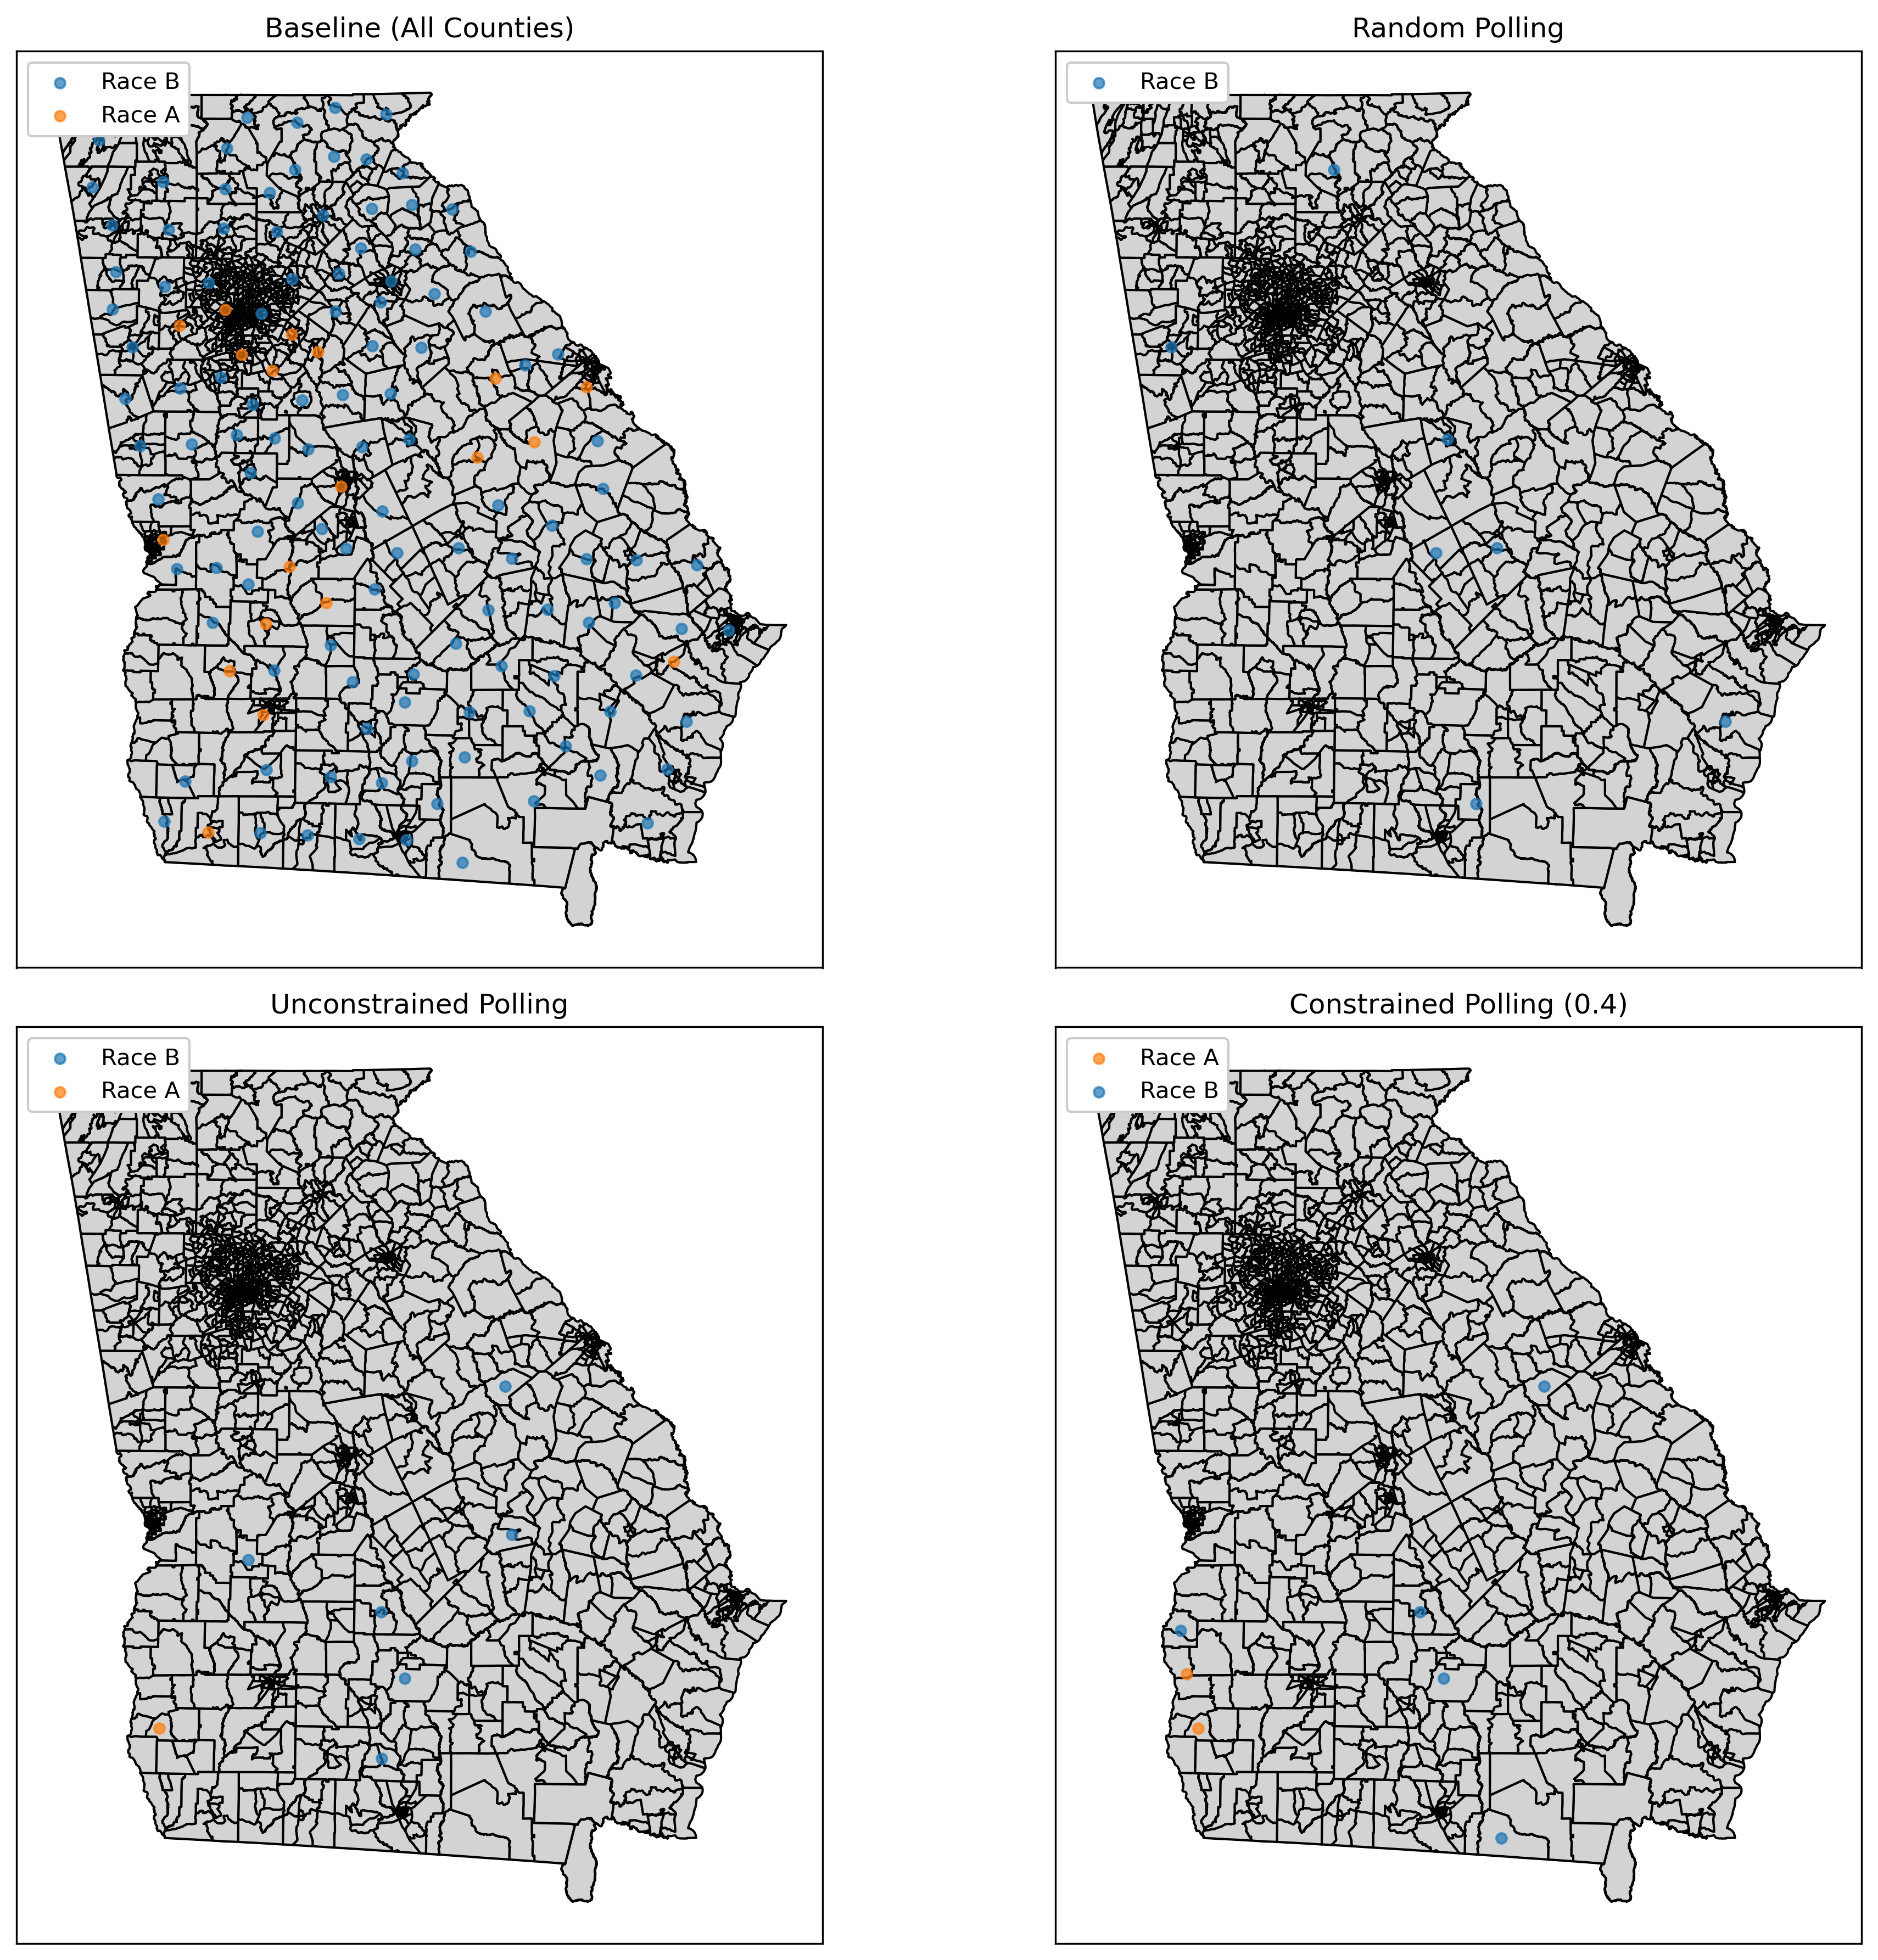

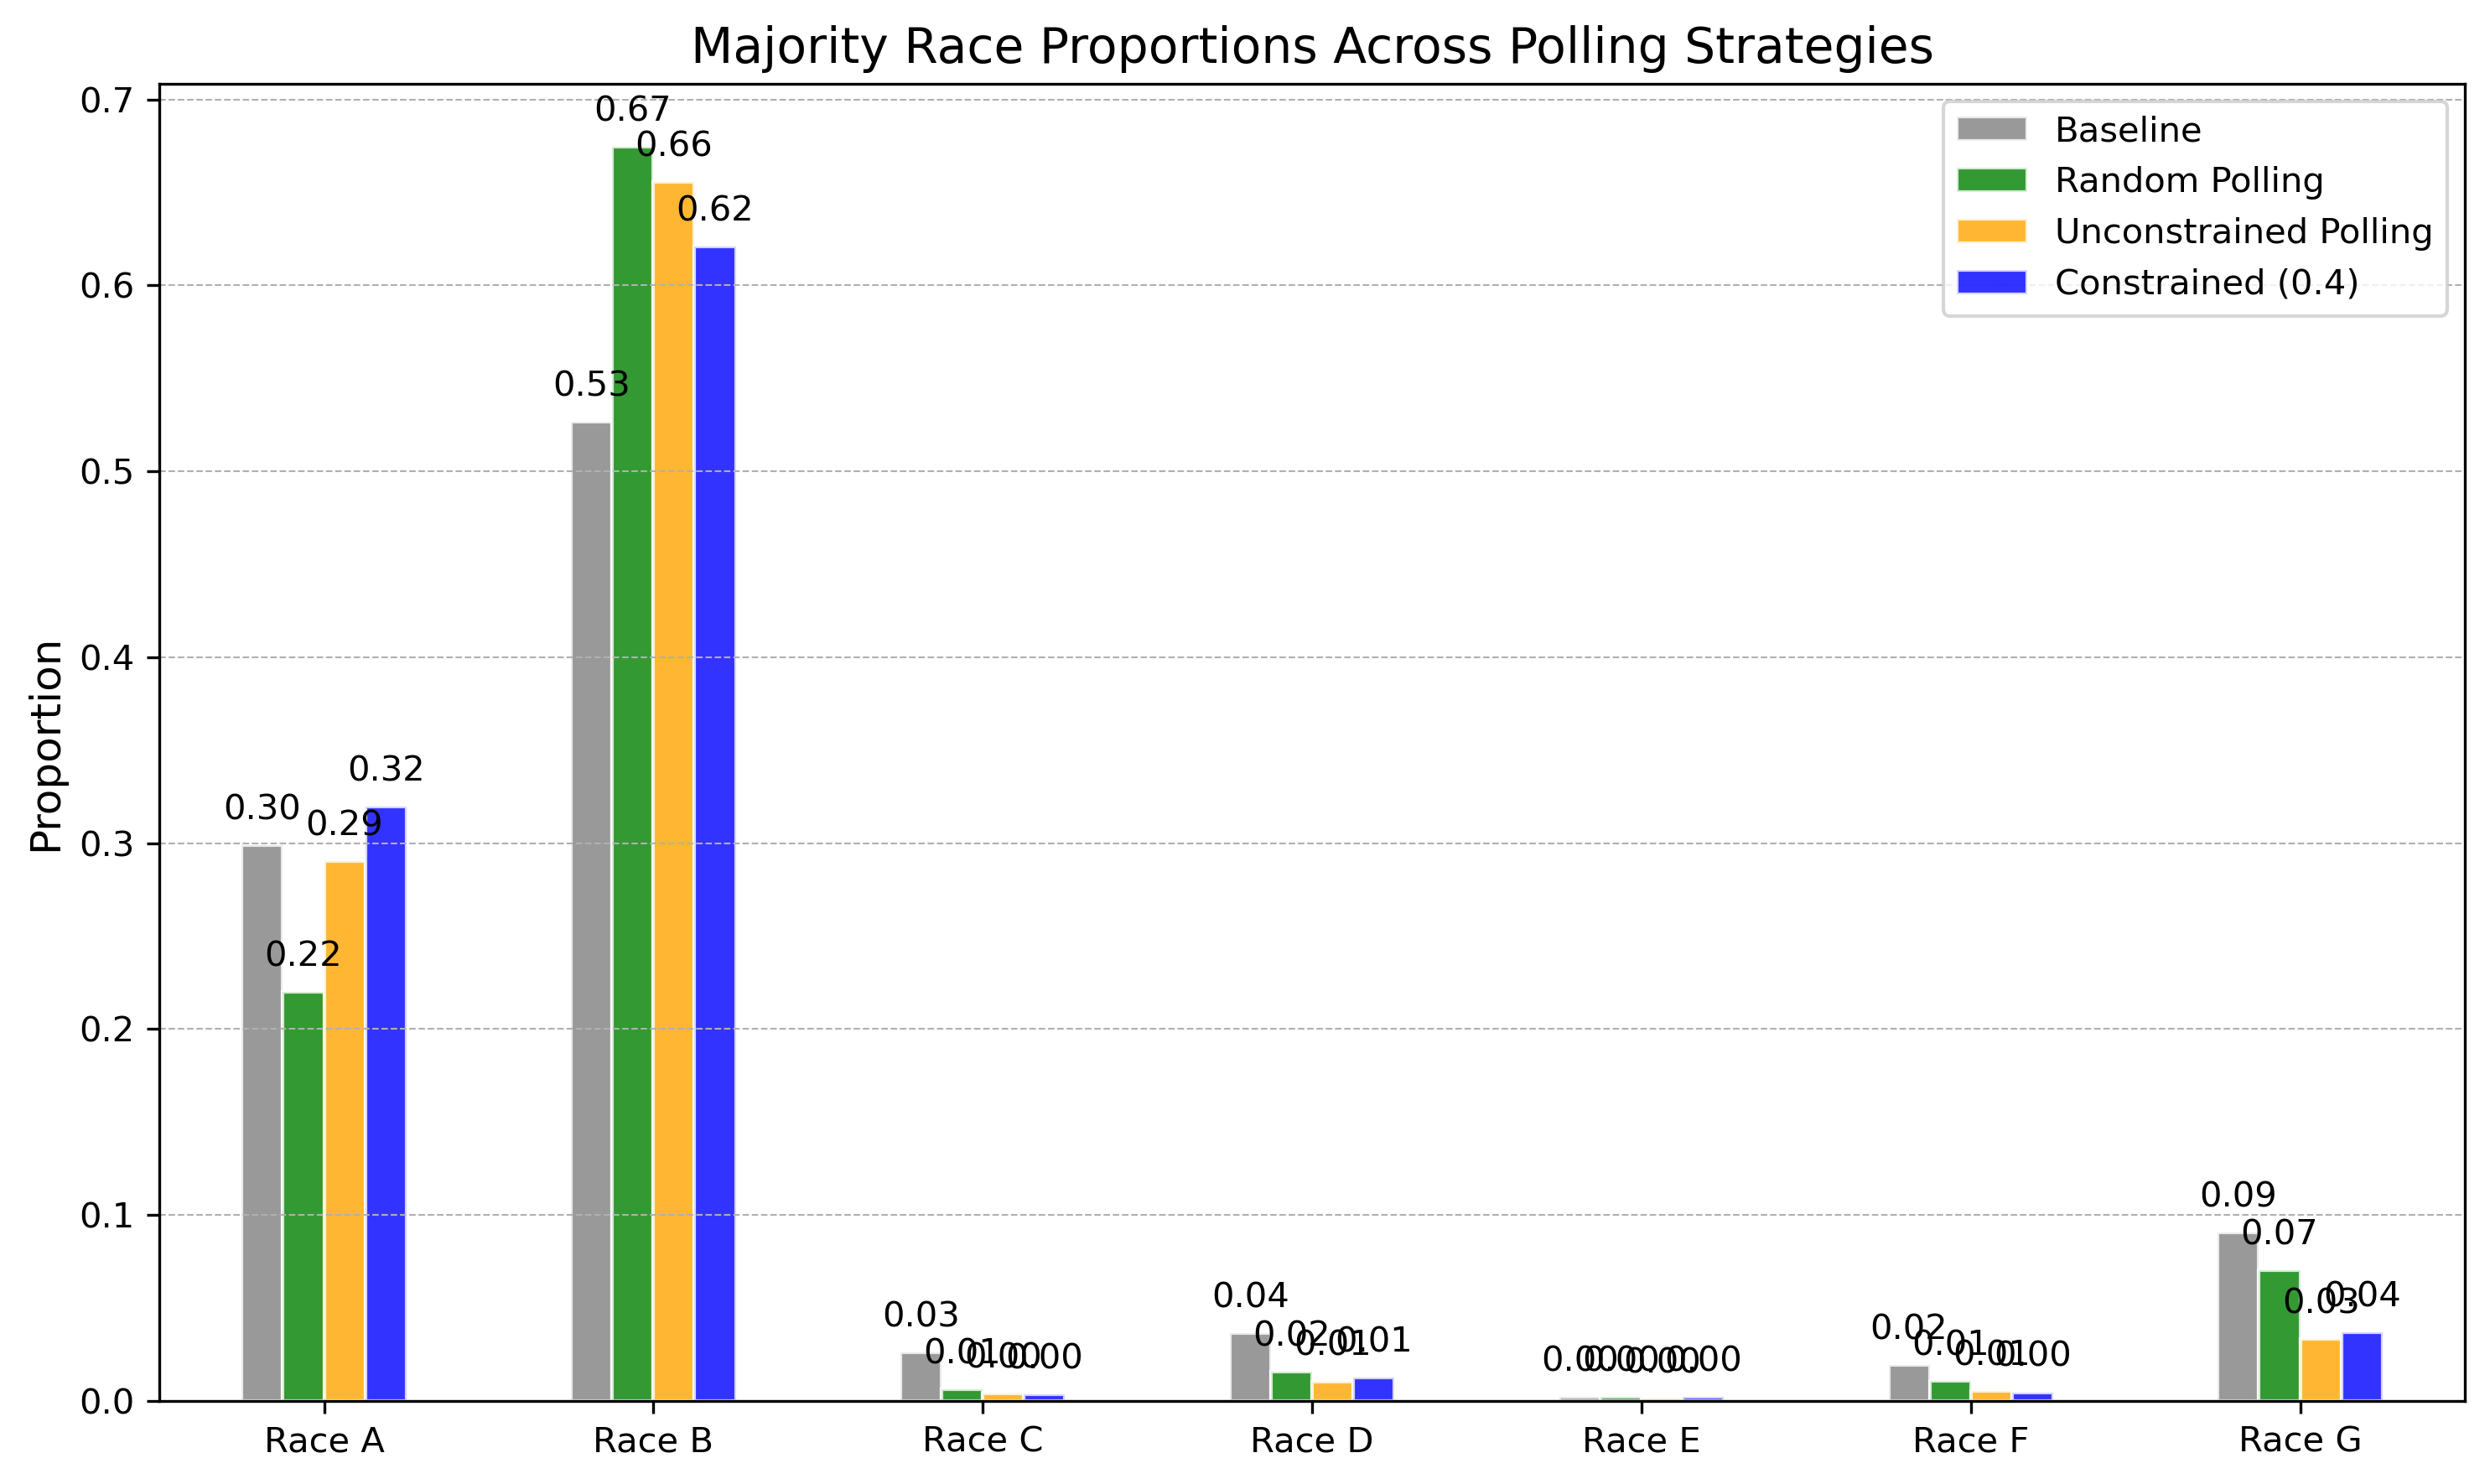

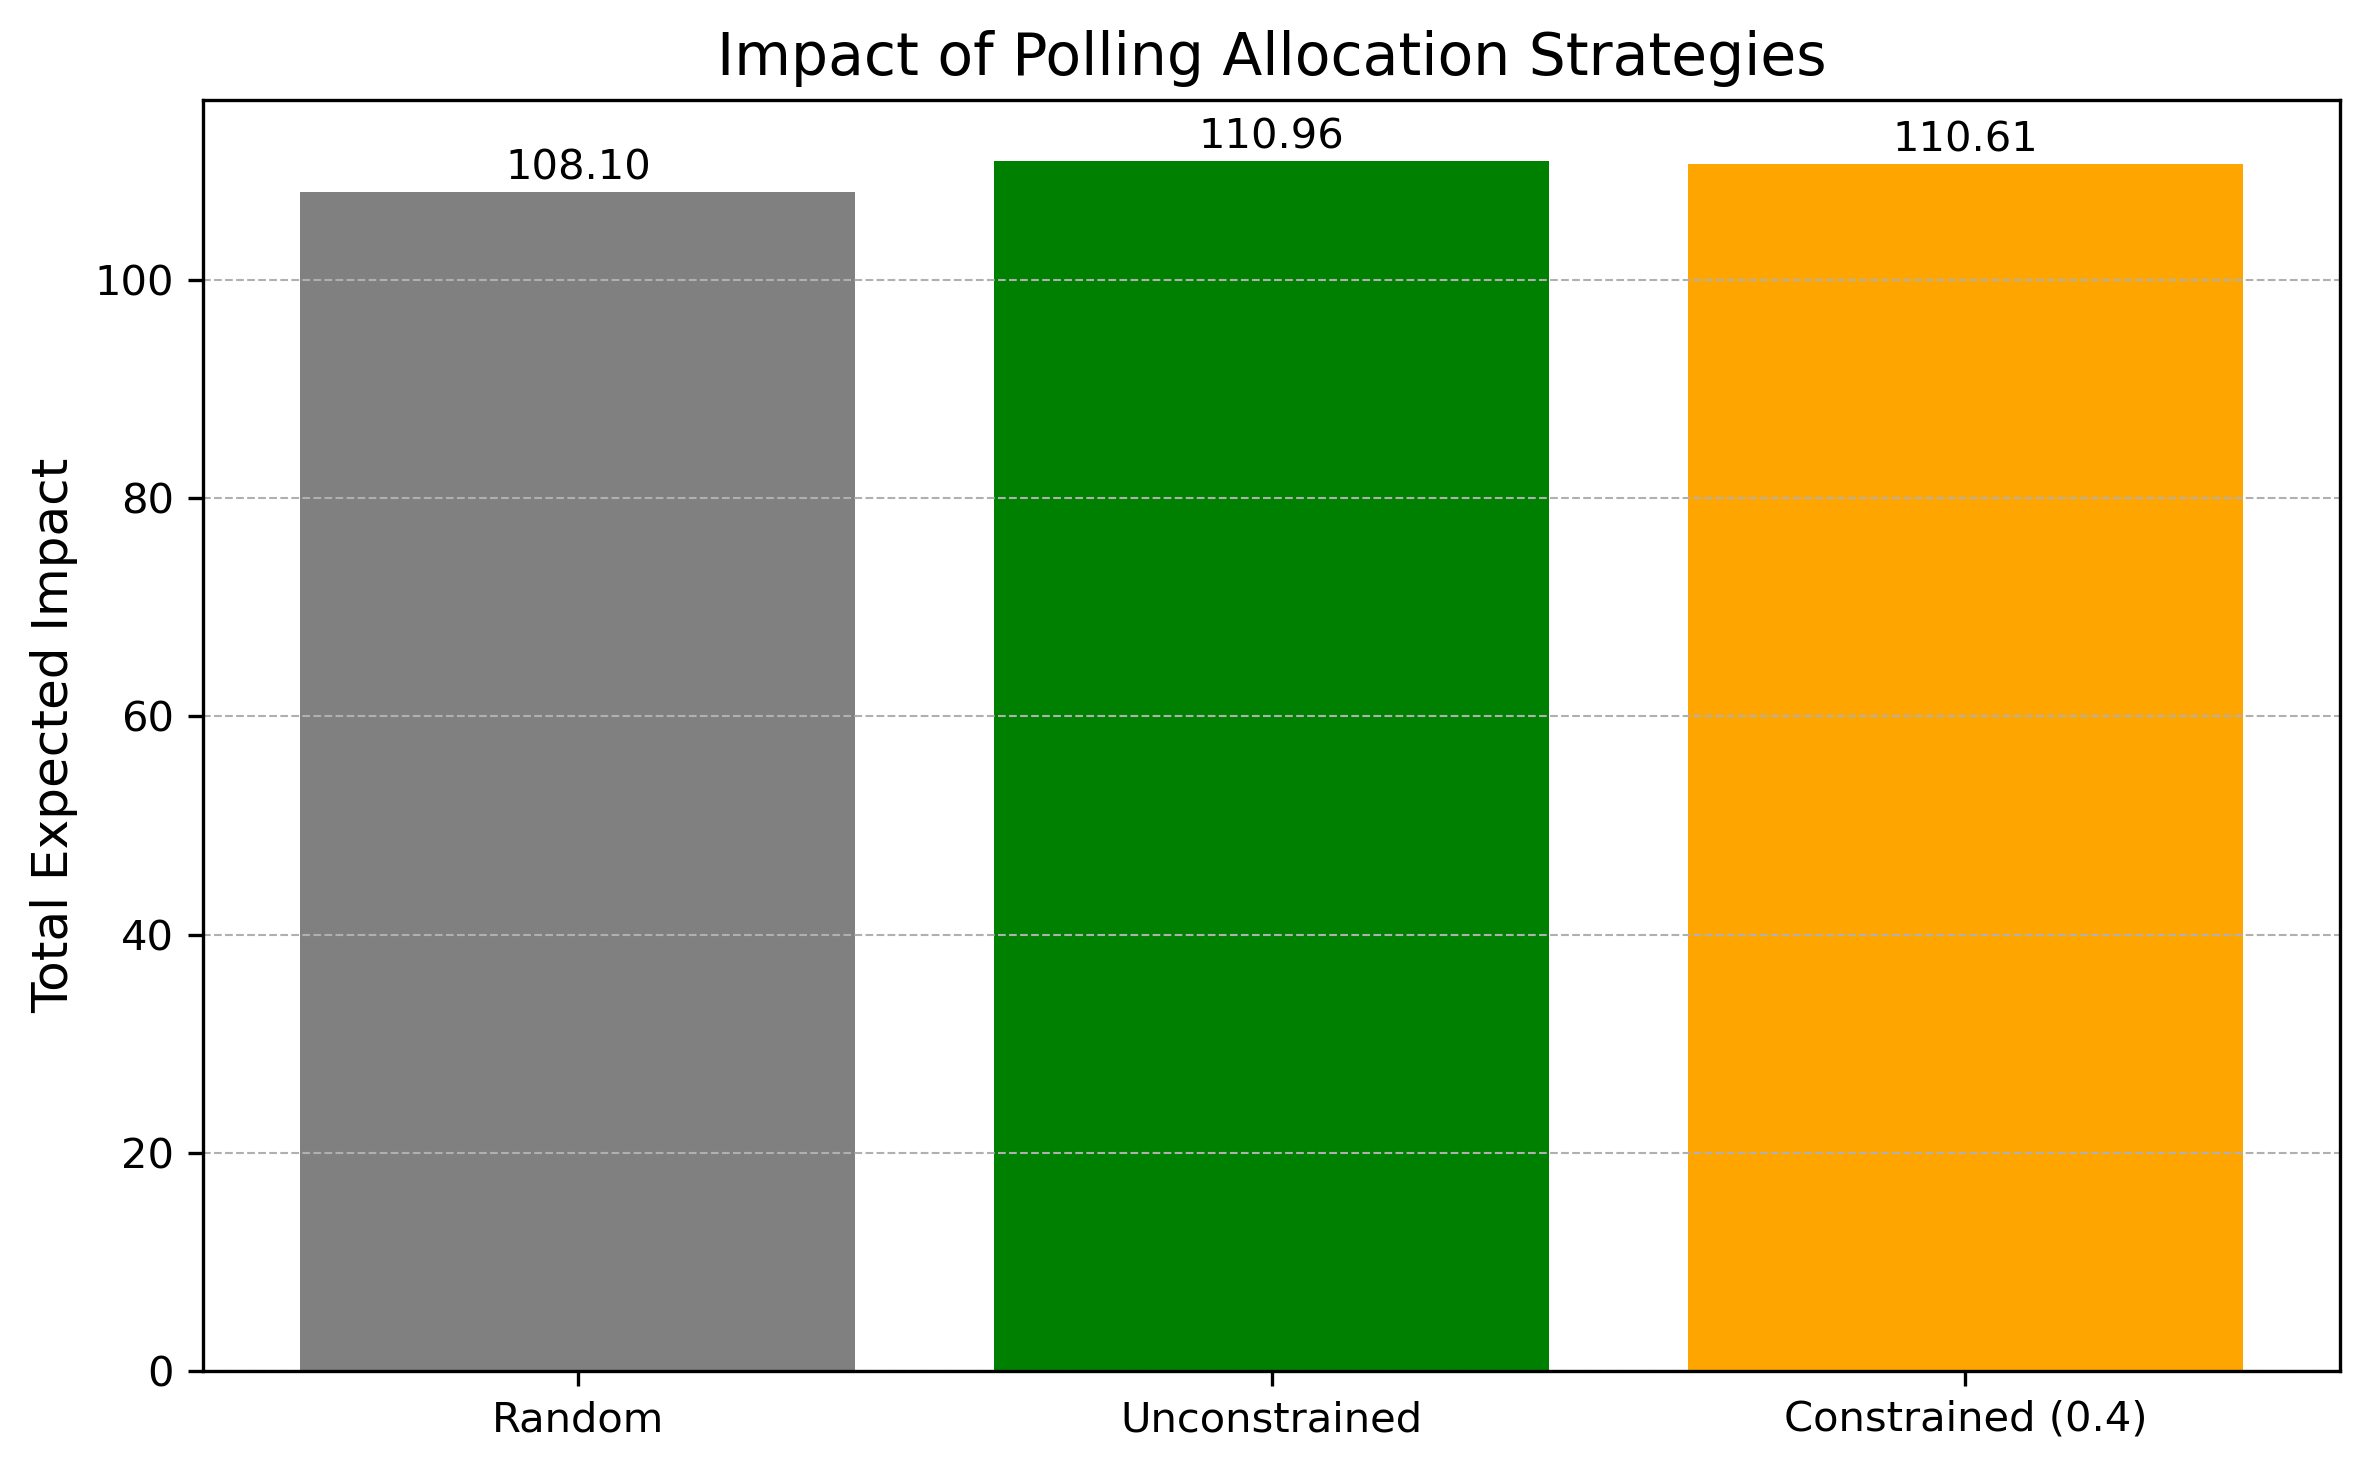

In [7]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# -------------------------------
# Load Data & Define Constants
# -------------------------------
constrained_path_0_4 = 'tight_tau_solution.npy'  # constrained tau = 0.4
unconstrained_path = 'no_tau_solution.npy'       # unconstrained tau

NUM_COUNTIES = df.shape[0]
race_columns = ['registered_A', 'registered_B', 'registered_C', 
                'registered_D', 'registered_E', 'registered_F', 'registered_G']

df['majority_race'] = df[race_columns].idxmax(axis=1).str.replace('registered_', '')

# Load intervention arrays
try:
    optimal_polling_constrained_0_4 = np.load(constrained_path_0_4)
    optimal_polling_unconstrained = np.load(unconstrained_path)
except FileNotFoundError as e:
    print(f"Error loading intervention files: {e}")
    exit()

# -------------------------------
# Generate Random Polling Allocations
# -------------------------------
num_random_polling = int(optimal_polling_constrained_0_4.sum())
random_polling = np.zeros(NUM_COUNTIES, dtype=int)
random_indices = np.random.choice(NUM_COUNTIES, size=num_random_polling, replace=False)
random_polling[random_indices] = 1

print(f"Constrained Tau (0.4): {optimal_polling_constrained_0_4.sum()}")
print(f"Unconstrained Tau: {optimal_polling_unconstrained.sum()}")
print(f"Random Polling: {random_polling.sum()}")

# -------------------------------
# Define County Groups
# -------------------------------
all_counties_baseline = df[df['n_poll'] == 0]
unique_to_random = df[random_polling == 1]
unique_to_unconstrained = df[optimal_polling_unconstrained == 1]
unique_to_constrained_0_4 = df[optimal_polling_constrained_0_4 == 1]

# -------------------------------
# Function to Plot Maps
# -------------------------------
def plot_map(ax, title, counties, color_map):
    """Plot counties colored by majority race using a consistent color map."""
    try:
        boroughs = gpd.read_file(r'./ga_map/tl_2009_13_tract00.shp').to_crs("EPSG:4326")
        boroughs.plot(ax=ax, color='lightgray', edgecolor='black')
    except FileNotFoundError as e:
        print(f"Error loading shapefile: {e}")
        return
    
    for race in counties['majority_race'].unique():
        subset = counties[counties['majority_race'] == race]
        ax.scatter(subset['longitude'], subset['latitude'], 
                   color=color_map[race], label=f"Race {race}", alpha=0.7, s=20)
    ax.set_title(title, fontsize=12)
    ax.legend(loc='upper left', framealpha=1)
    ax.set_xticks([])
    ax.set_yticks([])

# Create color map
color_map = {race: plt.cm.tab10(i) for i, race in enumerate(df['majority_race'].unique())}

# Generate Plots
fig, axes = plt.subplots(2, 2, figsize=(14, 12), dpi=300)
axes = axes.ravel()
plot_map(axes[0], "Baseline (All Counties)", all_counties_baseline, color_map)
plot_map(axes[1], "Random Polling", unique_to_random, color_map)
plot_map(axes[2], "Unconstrained Polling", unique_to_unconstrained, color_map)
plot_map(axes[3], "Constrained Polling (0.4)", unique_to_constrained_0_4, color_map)
plt.tight_layout()
plt.show()

# -------------------------------
# Race Proportions Bar Plot
# -------------------------------
def calculate_proportion(data):
    counts = data[race_columns].sum()
    return counts / counts.sum()

race_df = pd.concat([
    calculate_proportion(all_counties_baseline), 
    calculate_proportion(unique_to_random), 
    calculate_proportion(unique_to_unconstrained), 
    calculate_proportion(unique_to_constrained_0_4)
], axis=1)

race_df.columns = ['Baseline', 'Random Polling', 'Unconstrained Polling', 'Constrained (0.4)']
race_df.index = [f"Race {col[-1]}" for col in race_columns]

fig, ax = plt.subplots(figsize=(10, 6), dpi=300)
race_df.plot.bar(ax=ax, rot=0, color=['gray', 'green', 'orange', 'blue'], edgecolor='white', alpha=0.8)
ax.set_ylabel('Proportion', fontsize=12)
ax.set_title('Majority Race Proportions Across Polling Strategies', fontsize=14)
ax.legend(loc='upper right', fontsize=10)
ax.grid(axis='y', linestyle='--', linewidth=0.5)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points', fontsize=10)

plt.tight_layout()
plt.show()


impacts = [calculate_total_impact(random_polling),
           calculate_total_impact(optimal_polling_unconstrained),
           calculate_total_impact(optimal_polling_constrained_0_4)]

labels = ['Random', 'Unconstrained', 'Constrained (0.4)']
fig, ax = plt.subplots(figsize=(8, 5), dpi=300)
bars = ax.bar(labels, impacts, color=['gray', 'green', 'orange'])
ax.set_ylabel('Total Expected Impact', fontsize=12)
ax.set_title('Impact of Polling Allocation Strategies', fontsize=14)
ax.grid(axis='y', linestyle='--', linewidth=0.5)

for bar in bars:
    height = bar.get_height()
    ax.annotate(f"{height:.2f}", (bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', fontsize=10)

plt.tight_layout()
plt.show()


In [13]:
df['majority_race'].count()

159

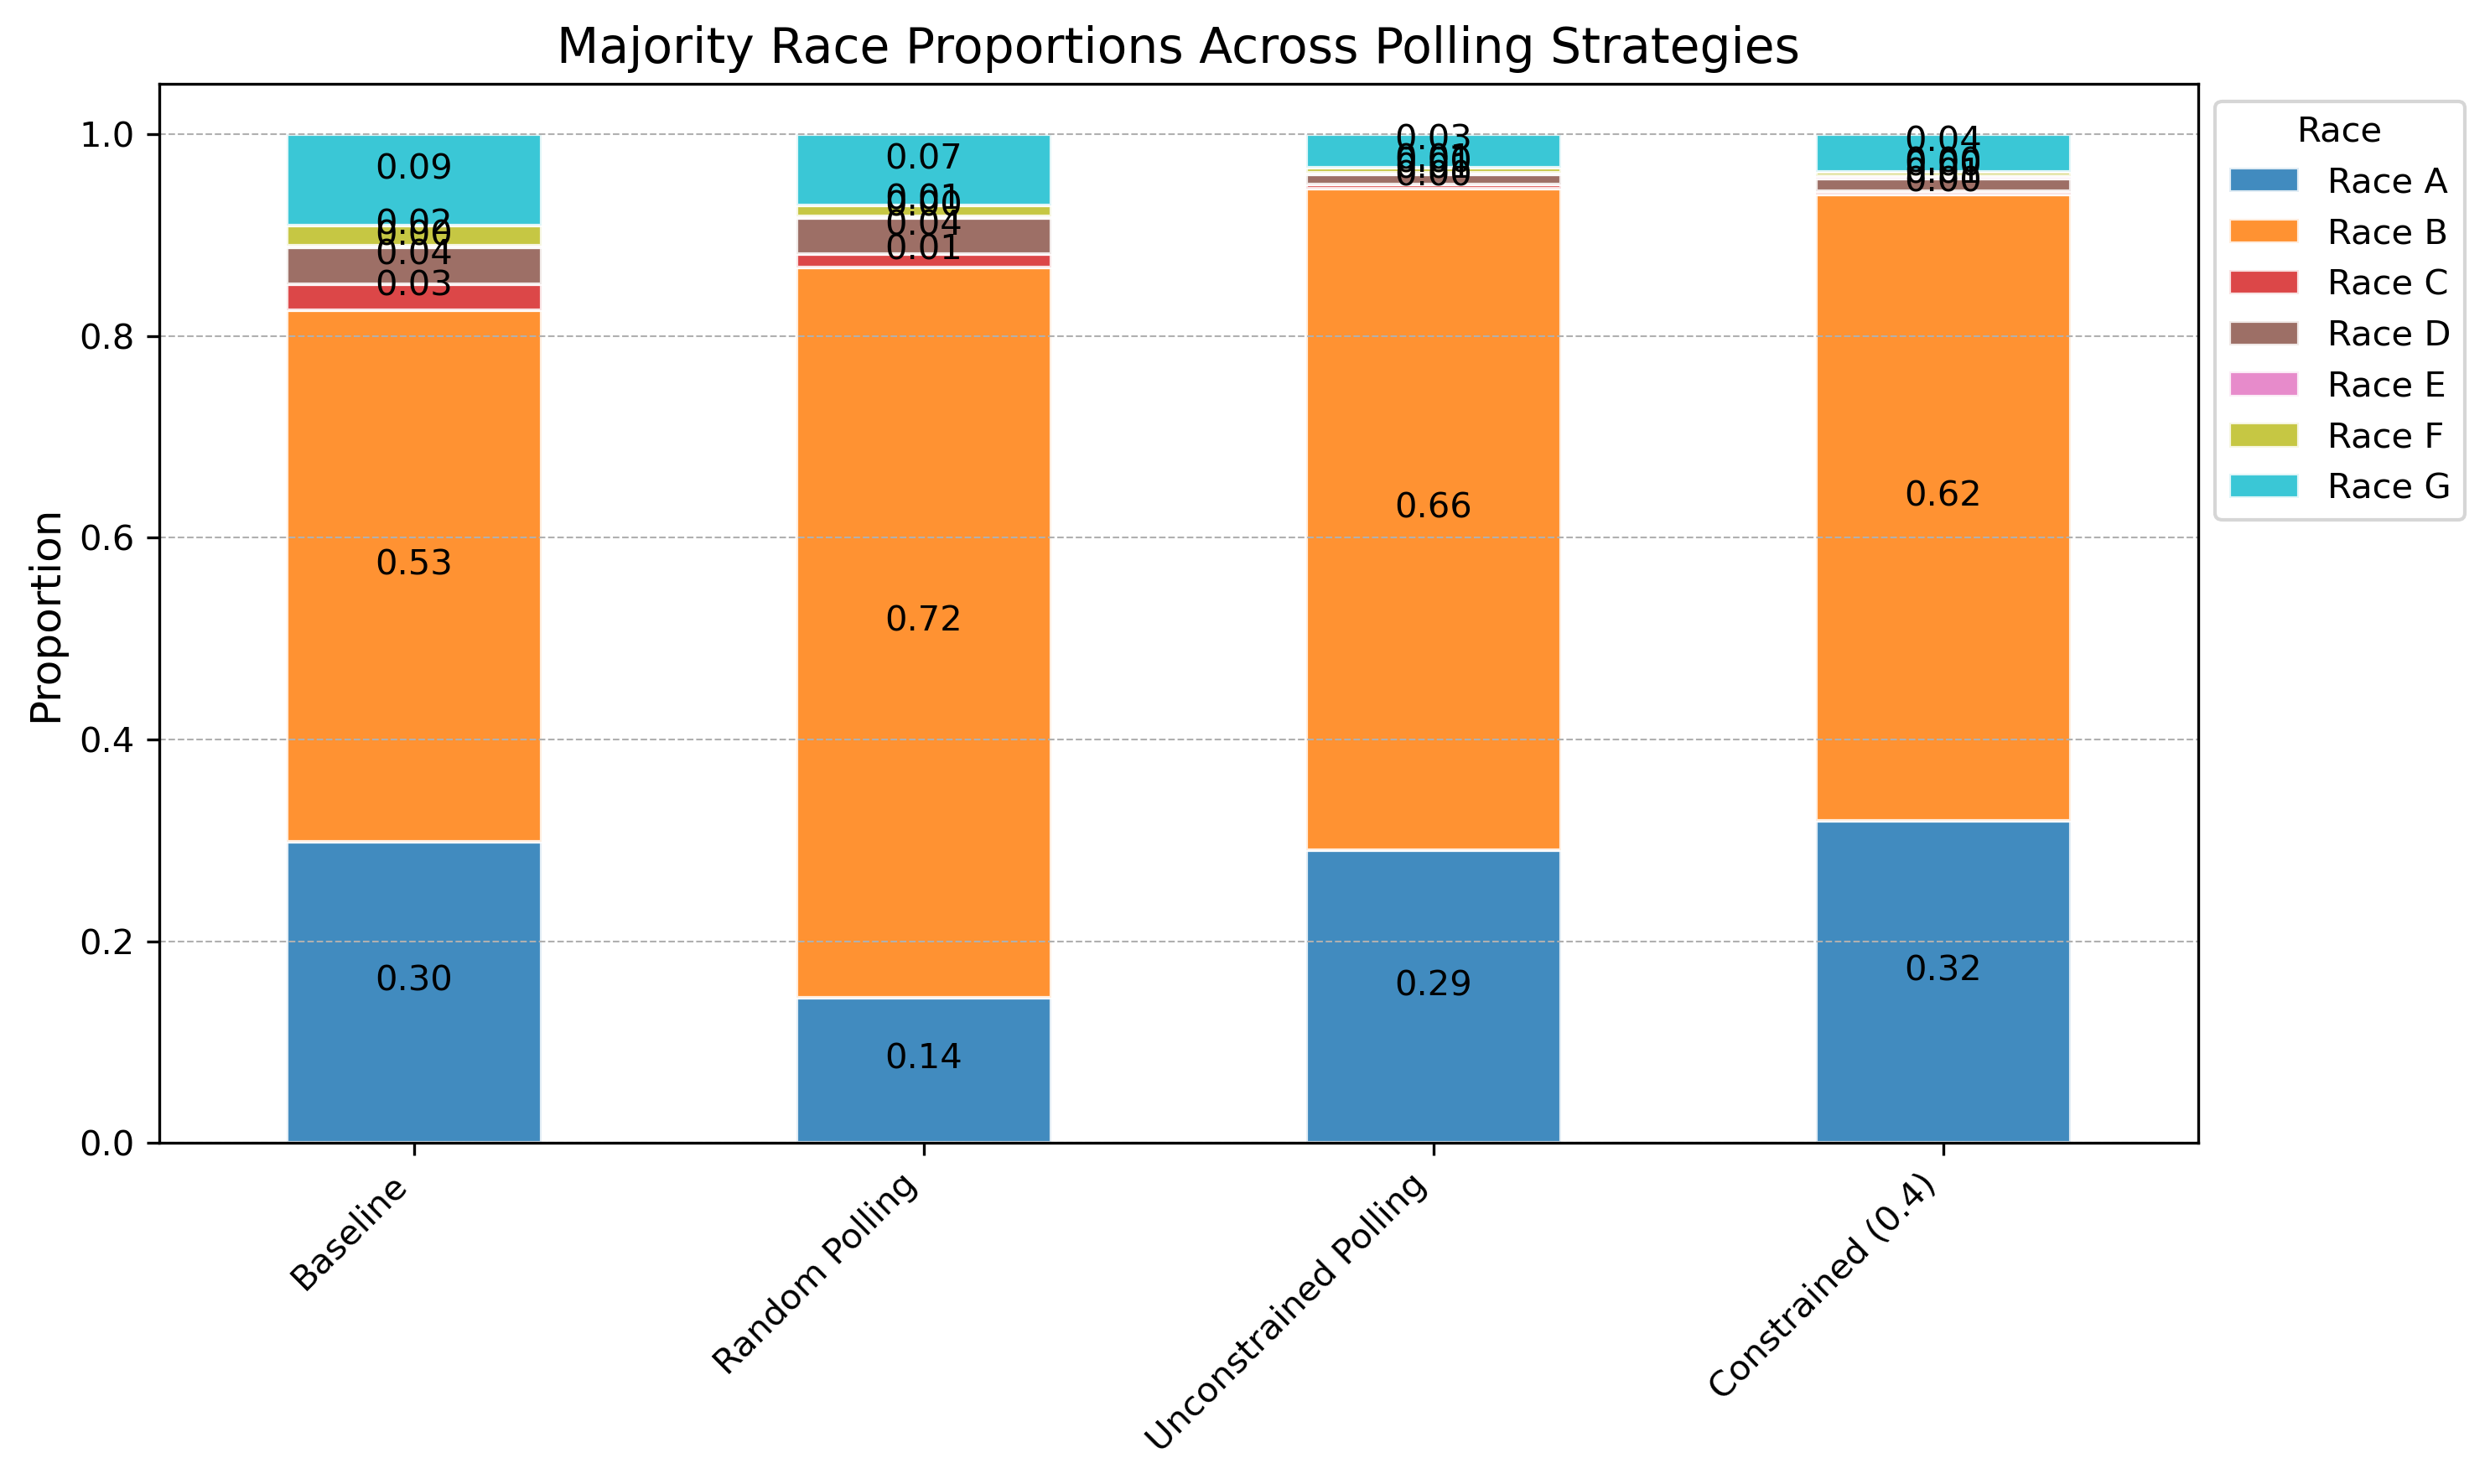

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Normalize the data so each strategy sums to 1
race_df_normalized = race_df.div(race_df.sum(axis=0), axis=1)

# Plot
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)
race_df_normalized.T.plot(kind='bar', stacked=True, ax=ax, colormap="tab10", edgecolor='white', alpha=0.85)

# Formatting
ax.set_ylabel('Proportion', fontsize=12)
ax.set_title('Majority Race Proportions Across Polling Strategies', fontsize=14)
ax.legend(title="Race", loc='upper left', bbox_to_anchor=(1, 1))
ax.grid(axis='y', linestyle='--', linewidth=0.5)

# Add value labels for significant proportions
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", label_type="center", fontsize=10, color='black', padding=3)

plt.xticks(rotation=45, ha='right', fontsize=10)
plt.tight_layout()
plt.show()


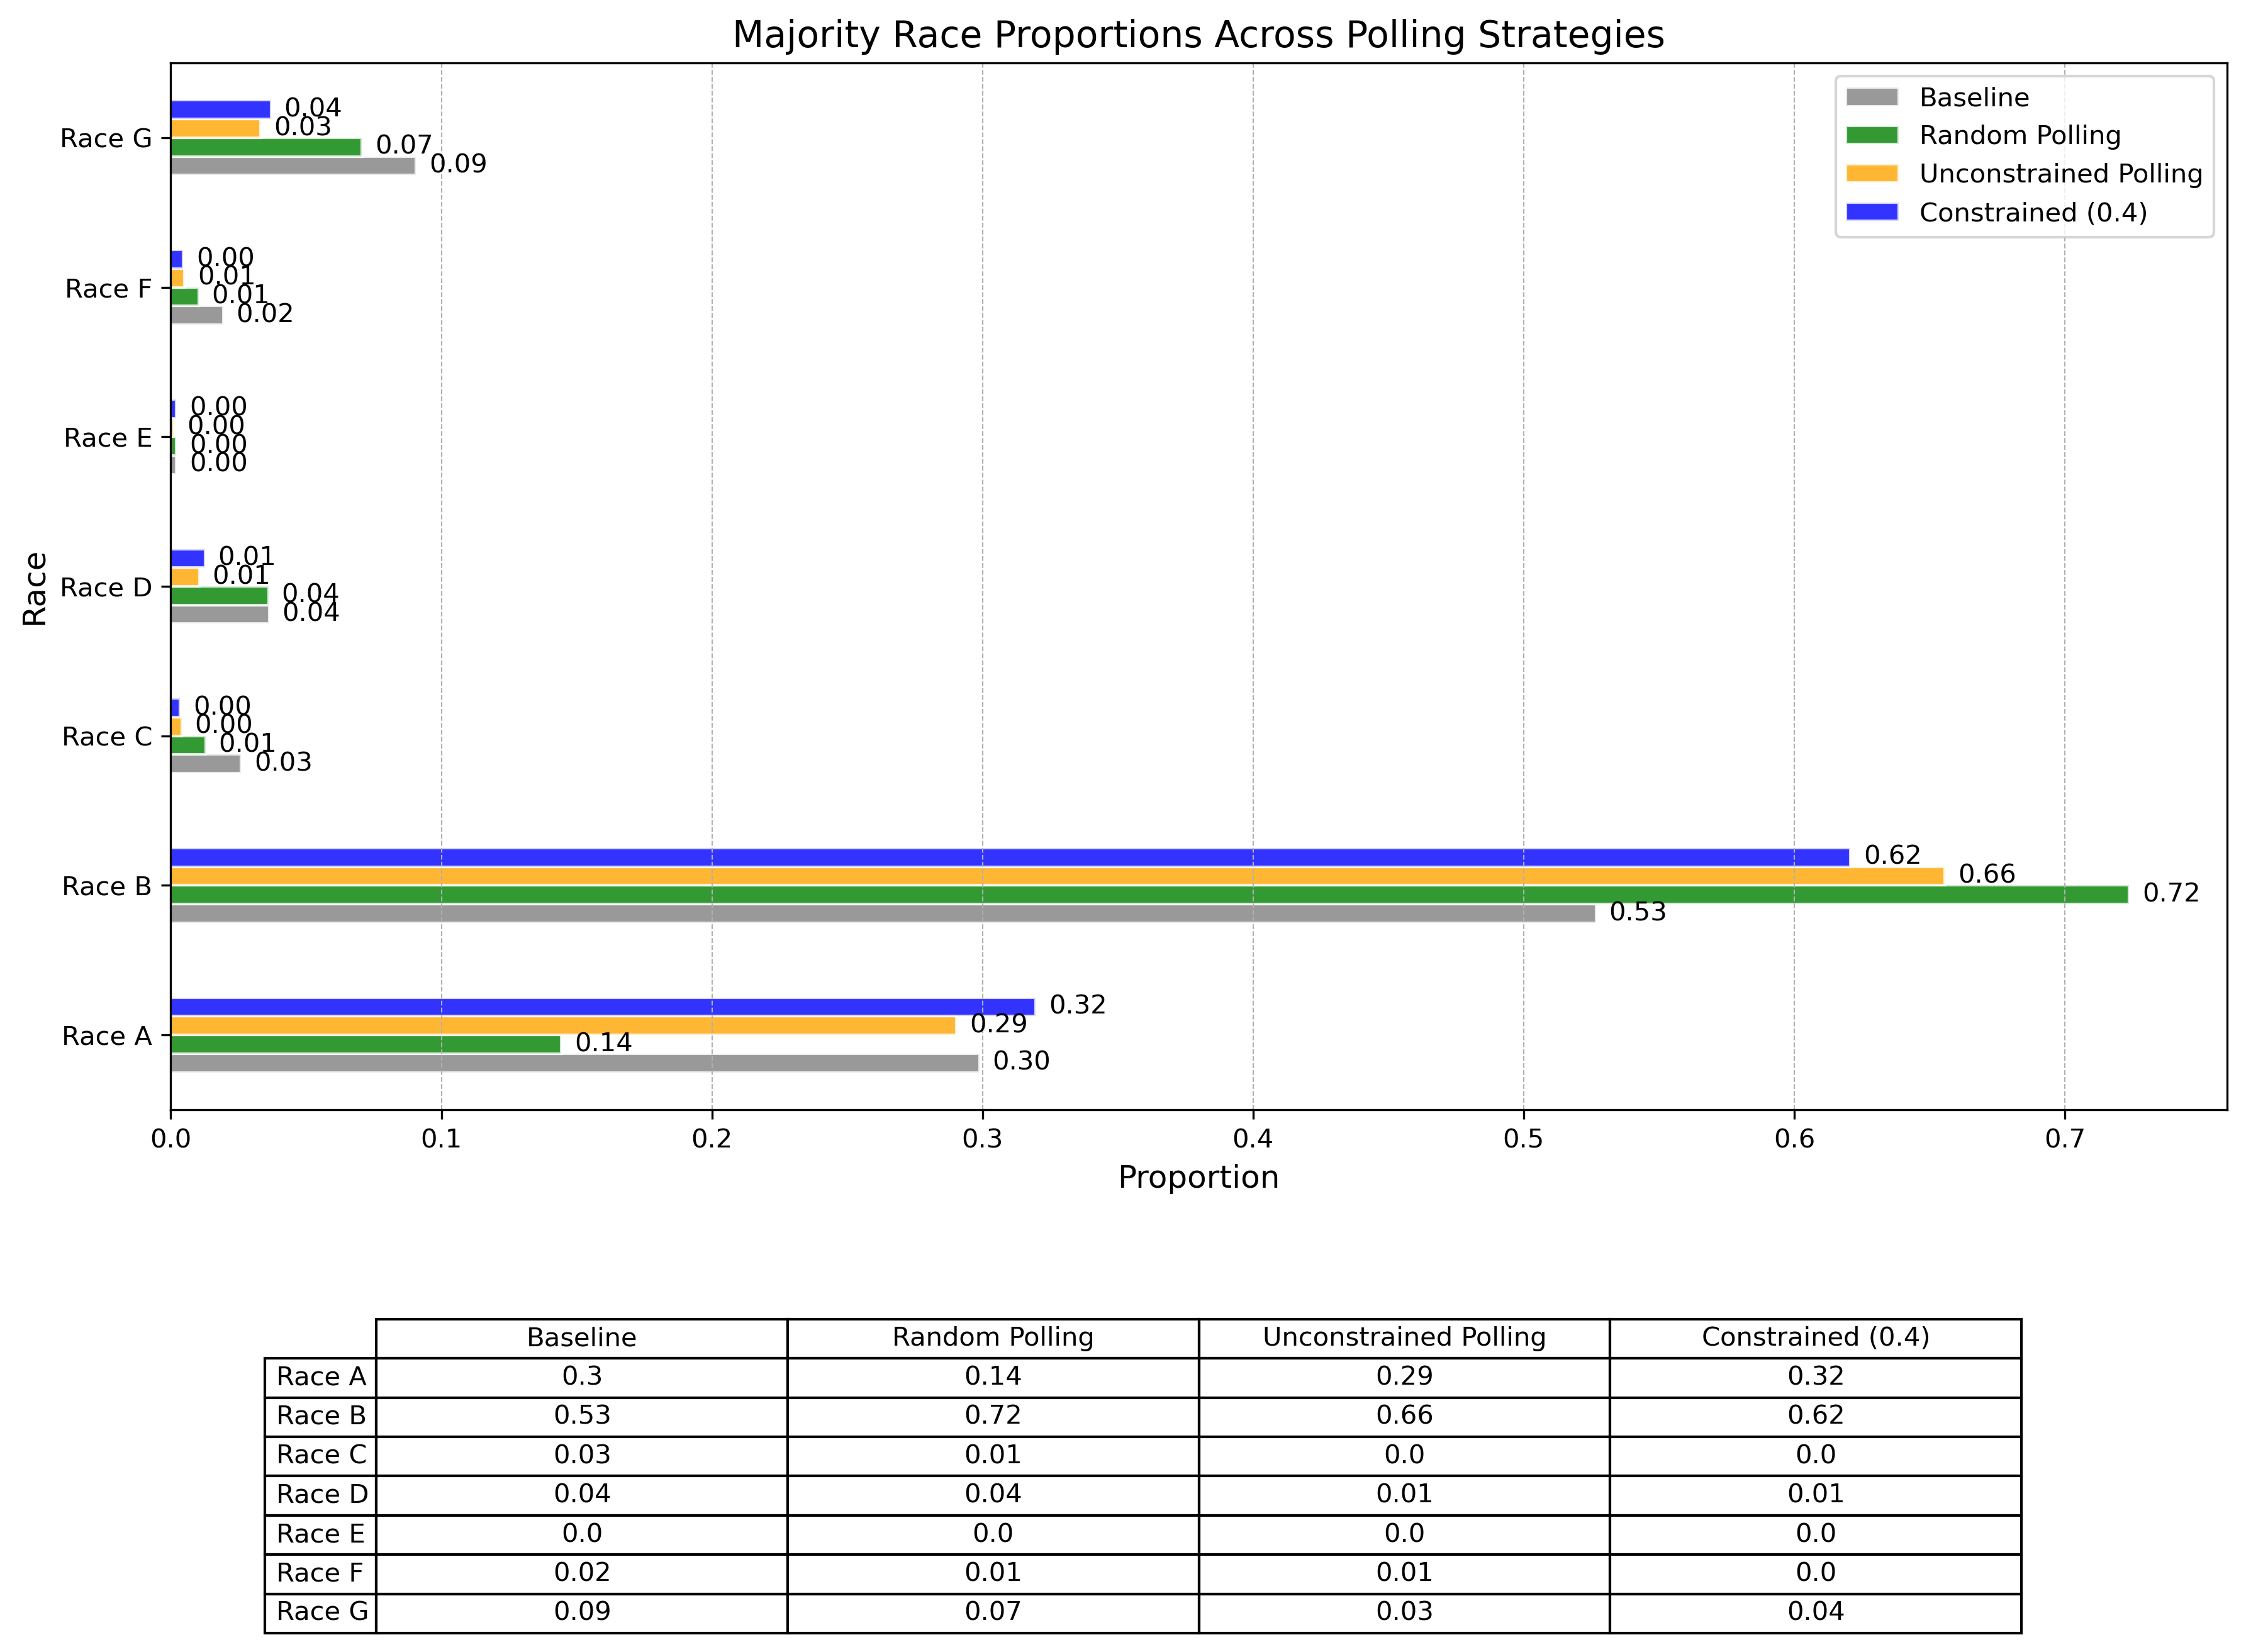

In [9]:
import matplotlib.pyplot as plt
import pandas as pd

# -------------------------------
# Race Proportions Bar Plot (Improved Visualization)
# -------------------------------
def calculate_proportion(data):
    """Calculate the proportion of each race in the given data."""
    counts = data[race_columns].sum()
    return counts / counts.sum()

# Calculate proportions for each group
race_df = pd.concat([
    calculate_proportion(all_counties_baseline), 
    calculate_proportion(unique_to_random), 
    calculate_proportion(unique_to_unconstrained), 
    calculate_proportion(unique_to_constrained_0_4)
], axis=1)

race_df.columns = ['Baseline', 'Random Polling', 'Unconstrained Polling', 'Constrained (0.4)']
race_df.index = [f"Race {col[-1]}" for col in race_columns]

# Create a horizontal bar plot
fig, ax = plt.subplots(figsize=(12, 8), dpi=300)
race_df.plot.barh(ax=ax, color=['gray', 'green', 'orange', 'blue'], edgecolor='white', alpha=0.8)
ax.set_xlabel('Proportion', fontsize=12)
ax.set_ylabel('Race', fontsize=12)
ax.set_title('Majority Race Proportions Across Polling Strategies', fontsize=14)
ax.legend(loc='upper right', fontsize=10)
ax.grid(axis='x', linestyle='--', linewidth=0.5)

# Add number labels to bars
for p in ax.patches:
    width = p.get_width()
    ax.annotate(f"{width:.2f}", 
                (width, p.get_y() + p.get_height() / 2), 
                ha='left', va='center', xytext=(5, 0), 
                textcoords='offset points', fontsize=10)

# Add a table below the plot
table = plt.table(
    cellText=race_df.round(2).values,
    rowLabels=race_df.index,
    colLabels=race_df.columns,
    cellLoc='center',
    loc='bottom',
    bbox=[0.1, -0.5, 0.8, 0.3]  # Adjust bbox to position the table
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)

# Adjust layout to make room for the table
plt.subplots_adjust(left=0.2, bottom=0.4)

plt.tight_layout()
plt.show()

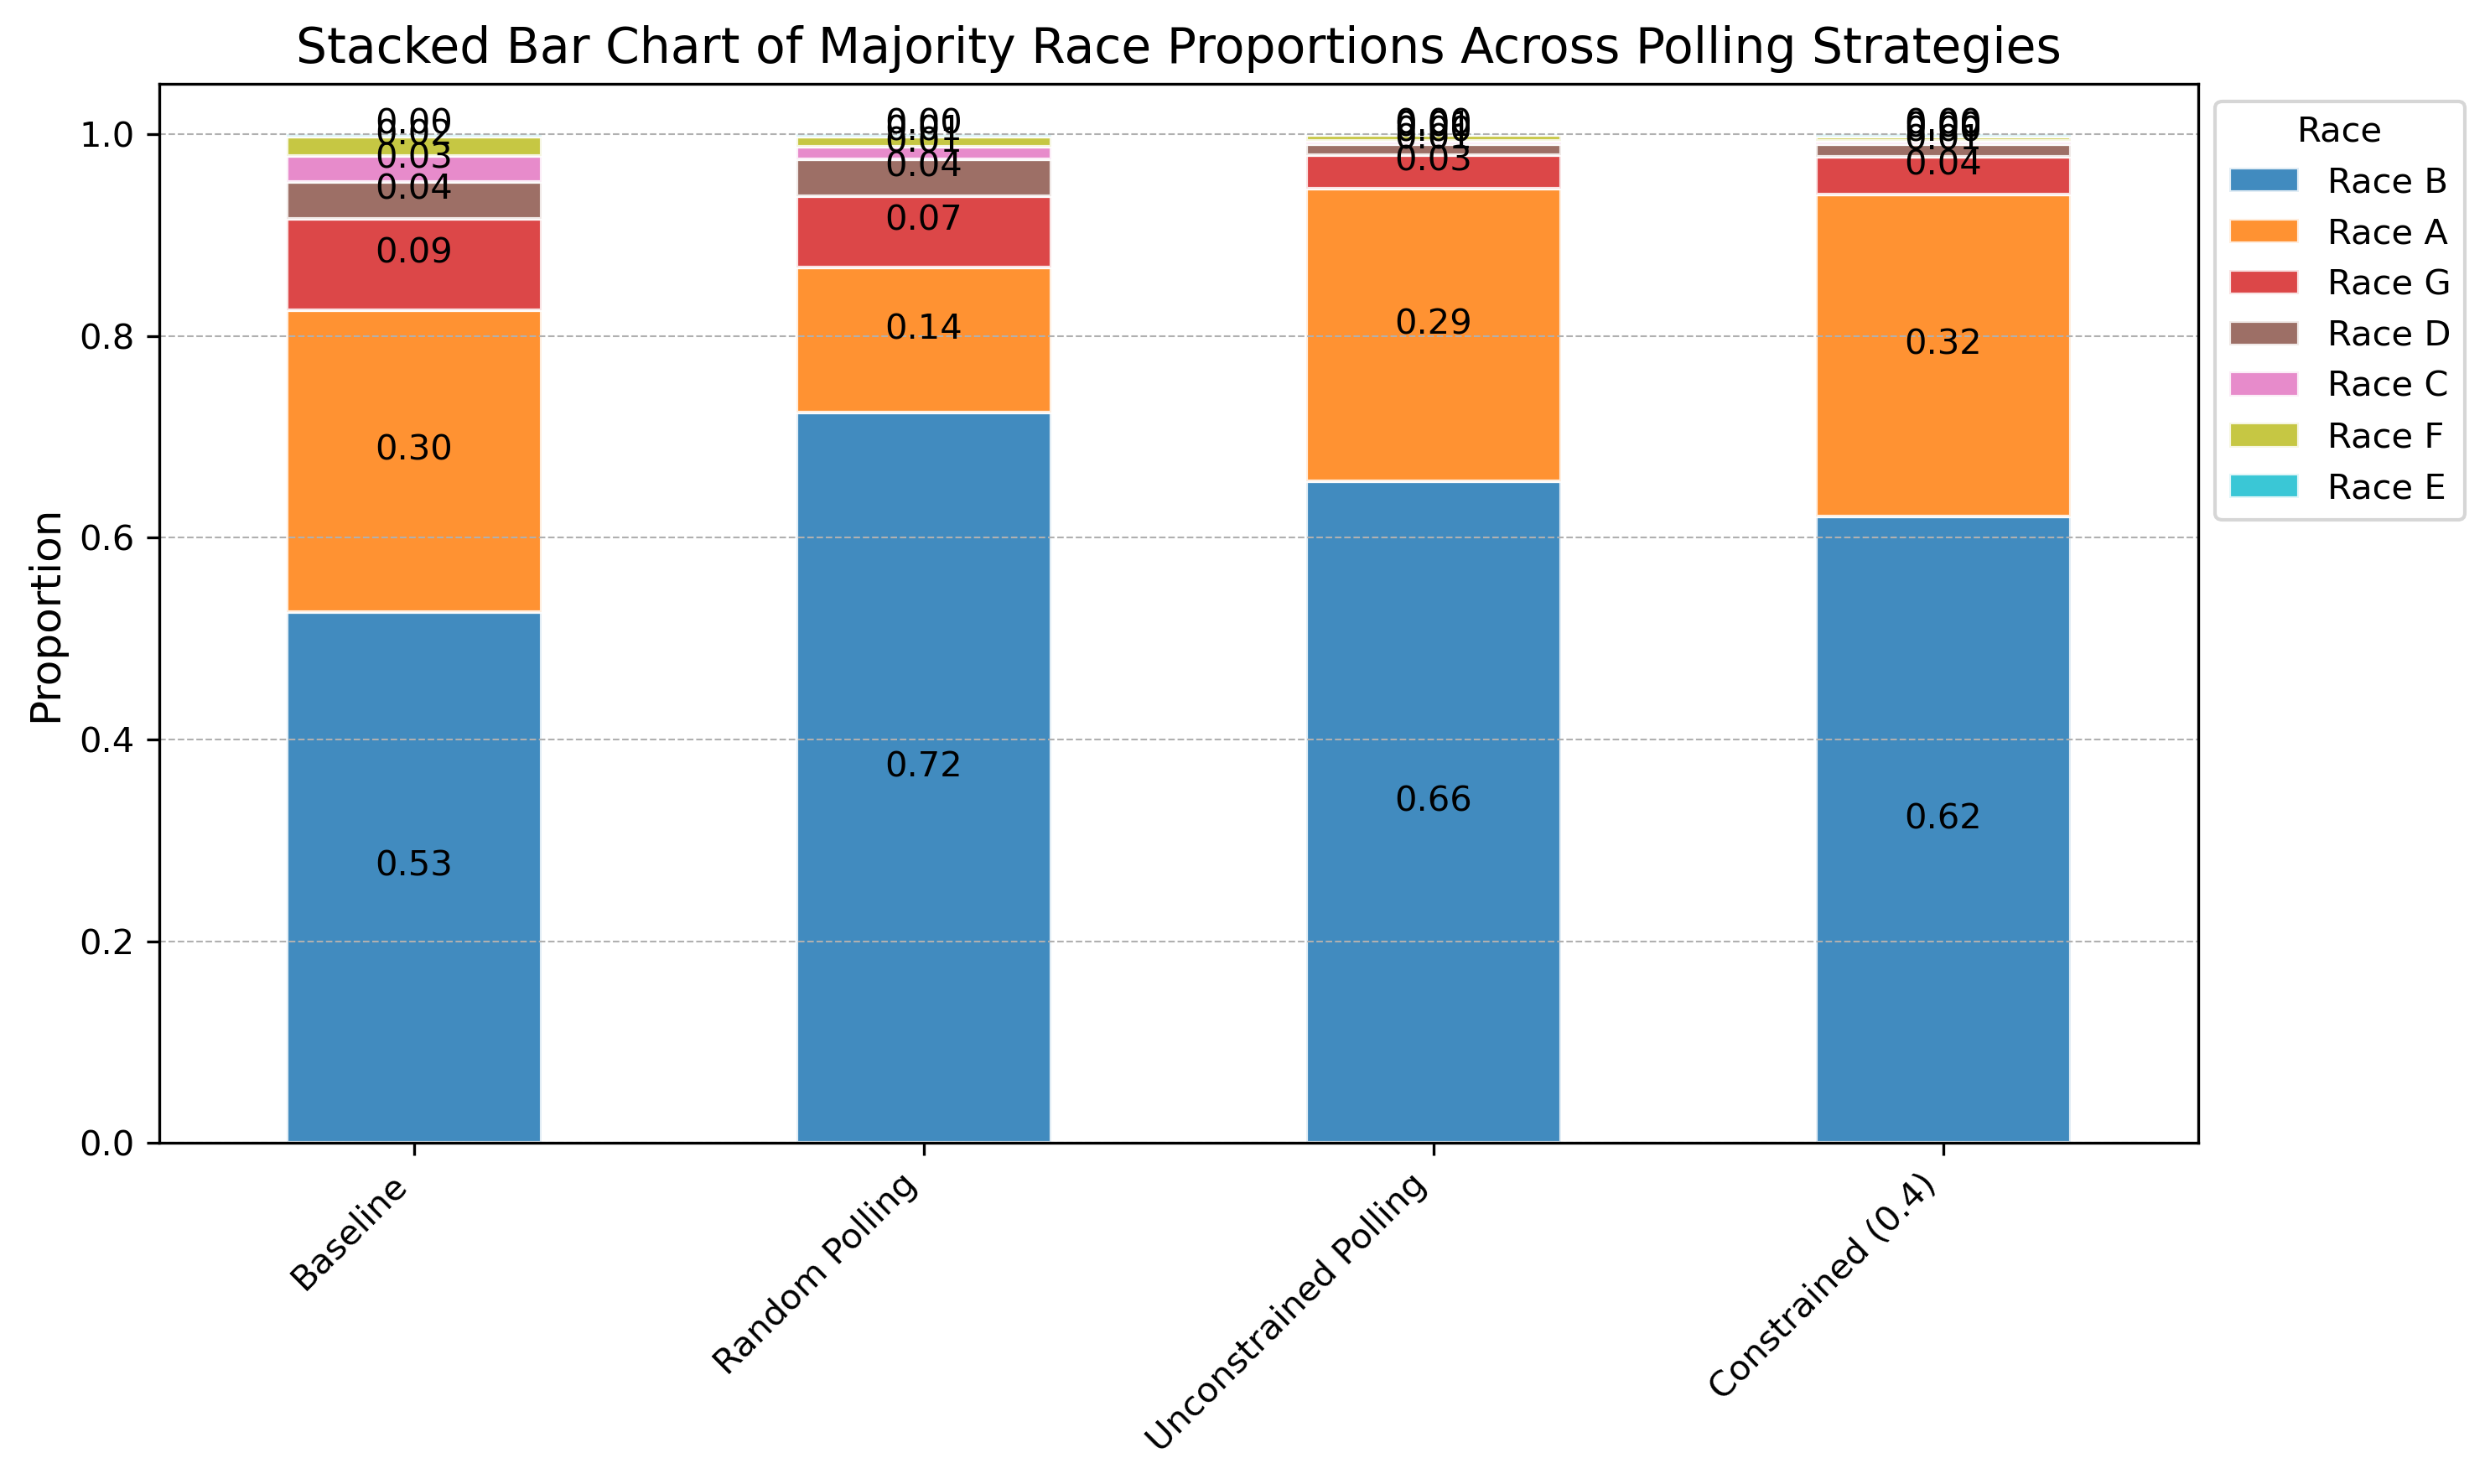

0.04615488547774884

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Sort race proportions from most to least for better visualization
sorted_race_df = race_df.sum(axis=1).sort_values(ascending=False).index
race_df_sorted = race_df.loc[sorted_race_df]

# Check if Race C is really zero across all strategies
race_c_value = race_df.loc['Race C'].sum()

# Normalize the sorted data
race_df_normalized_sorted = race_df_sorted.div(race_df_sorted.sum(axis=0), axis=1)

# Plot
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)
race_df_normalized_sorted.T.plot(kind='bar', stacked=True, ax=ax, colormap="tab10", edgecolor='white', alpha=0.85)

# Formatting
ax.set_ylabel('Proportion', fontsize=12)
ax.set_title('Stacked Bar Chart of Majority Race Proportions Across Polling Strategies', fontsize=14)
ax.legend(title="Race", loc='upper left', bbox_to_anchor=(1, 1))
ax.grid(axis='y', linestyle='--', linewidth=0.5)

# Add value labels for significant proportions
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", label_type="center", fontsize=10, color='black', padding=3)

plt.xticks(rotation=45, ha='right', fontsize=10)
plt.tight_layout()
plt.show()

# Output Race C value
race_c_value
